# **4. Recovery Analysis (Hangover Effects)**
## Coast-to-Coast Travel Analysis

This notebook examines:
- Performance in games FOLLOWING coast-to-coast travel
- How many games does it take to recover?
- Impact of rest days between games
- Cumulative fatigue from multiple trips

**Output**: Recovery patterns and hangover effect timelines

---
## **Load Data**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats

# Load enhanced schedule data
schedules = pd.read_csv('data_schedules_with_travel.csv')
schedules['gameday'] = pd.to_datetime(schedules['gameday'])


---
## **Identify Post-Travel Games**

For each team, find games that occur after coast-to-coast travel

In [37]:
# Create team schedule with all games (home and away)
all_teams = pd.unique(schedules[['home_team', 'away_team']].values.ravel())

team_schedules = []

for team in all_teams:
    # Get all games for this team
    home_games = schedules[schedules['home_team'] == team].copy()
    home_games['is_home'] = True
    home_games['team'] = team
    home_games['opponent'] = home_games['away_team']
    home_games['team_score'] = home_games['home_score']
    home_games['opp_score'] = home_games['away_score']
    home_games['travel_tz'] = 0  # No travel for home games
    
    away_games = schedules[schedules['away_team'] == team].copy()
    away_games['is_home'] = False
    away_games['team'] = team
    away_games['opponent'] = away_games['home_team']
    away_games['team_score'] = away_games['away_score']
    away_games['opp_score'] = away_games['home_score']
    away_games['travel_tz'] = away_games['tz_crossed']
    
    # Combine
    team_games = pd.concat([home_games, away_games])
    team_games = team_games.sort_values('gameday')
    
    # Add game number
    team_games['game_num'] = range(1, len(team_games) + 1)
    
    # Flag coast-to-coast games
    team_games['is_c2c'] = (team_games['travel_tz'] == 3) & (~team_games['is_home'])
    
    team_schedules.append(team_games)

full_schedule = pd.concat(team_schedules, ignore_index=True)

In [38]:
# Identify post-travel games
full_schedule = full_schedule.sort_values(['team', 'season', 'week'])
full_schedule['prev_c2c'] = full_schedule.groupby(['team', 'season'])['is_c2c'].shift(1).fillna(False)
full_schedule['days_since_prev_game'] = full_schedule.groupby(['team', 'season'])['gameday'].diff().dt.days

# Calculate win/loss
full_schedule['win'] = (full_schedule['team_score'] > full_schedule['opp_score']).astype(int)

print(f"Post-travel games identified: {full_schedule['prev_c2c'].sum()}")

Post-travel games identified: 96


/var/folders/v_/zk3l9gks2t3g19x98y2g8skw0000gn/T/ipykernel_44032/3941847973.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_schedule['prev_c2c'] = full_schedule.groupby(['team', 'season'])['is_c2c'].shift(1).fillna(False)


---
## **Calculate Recovery Metrics**

How does performance change in post-travel games?

In [39]:
# Define categories
baseline = full_schedule[(~full_schedule['is_c2c']) & (~full_schedule['prev_c2c'])]
during_c2c = full_schedule[full_schedule['is_c2c']]
after_c2c = full_schedule[full_schedule['prev_c2c']]

# Calculate win rates
recovery_stats = pd.DataFrame({
    'Category': ['Baseline (No Recent C2C)', 'During C2C Travel', '1 Game After C2C'],
    'Win Rate': [
        baseline['win'].mean() * 100,
        during_c2c['win'].mean() * 100,
        after_c2c['win'].mean() * 100
    ],
    'Games': [
        len(baseline),
        len(during_c2c),
        len(after_c2c)
    ]
})

print("\n" + "="*70)
print("RECOVERY PATTERN: Win Rates\n")
print(recovery_stats.to_string(index=False))
print("="*70)


RECOVERY PATTERN: Win Rates

                Category  Win Rate  Games
Baseline (No Recent C2C) 50.287356   2088
       During C2C Travel 47.474747     99
        1 Game After C2C 40.625000     96


---
## **Visualize Recovery Timeline**

/var/folders/v_/zk3l9gks2t3g19x98y2g8skw0000gn/T/ipykernel_44032/3195094119.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


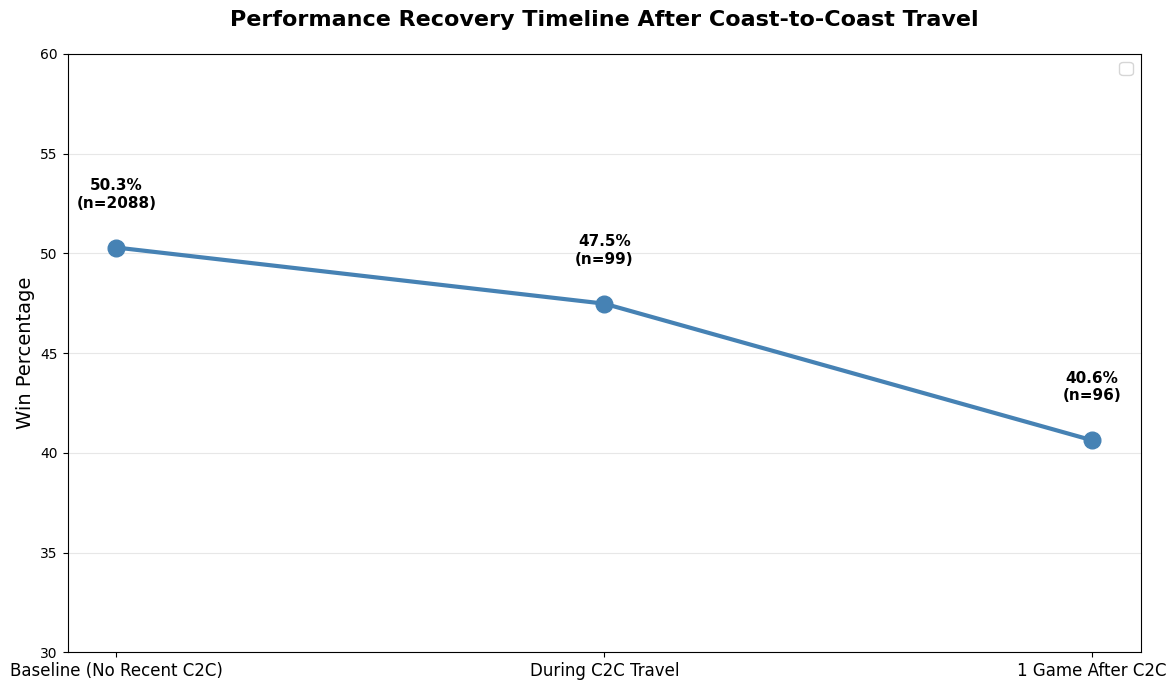

In [40]:
# Recovery timeline visualization
fig, ax = plt.subplots(figsize=(12, 7))

categories = recovery_stats['Category']
win_rates = recovery_stats['Win Rate']
games = recovery_stats['Games']

ax.plot(range(len(categories)), win_rates, marker='o', linewidth=3, 
        markersize=12, color='steelblue')


for i, (rate, n) in enumerate(zip(win_rates, games)):
    ax.text(i, rate + 2, f'{rate:.1f}%\n(n={n})', 
            ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Performance Recovery Timeline After Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(30, 60)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Impact of Rest Days**

Does more rest between games help recovery?

In [41]:
# Analyze rest days impact
post_c2c_with_rest = after_c2c[after_c2c['days_since_prev_game'].notna()].copy()

# Categorize rest
post_c2c_with_rest['rest_category'] = pd.cut(
    post_c2c_with_rest['days_since_prev_game'],
    bins=[0, 6, 7, 10, 100],
    labels=['Short Rest (3-6 days)', 'Normal Rest (7 days)', 
            'Extended Rest (8-10 days)', 'Long Rest (10+ days)']
)

rest_analysis = post_c2c_with_rest.groupby('rest_category', observed=True).agg({
    'win': ['mean', 'count']
}).reset_index()

rest_analysis.columns = ['Rest Period', 'Win Rate', 'Games']
rest_analysis['Win Rate'] = rest_analysis['Win Rate'] * 100

print("\n" + "="*70)
print("RECOVERY BY REST DAYS\n")
print(rest_analysis.to_string(index=False))
print("="*70)


RECOVERY BY REST DAYS

              Rest Period  Win Rate  Games
    Short Rest (3-6 days) 63.636364     11
     Normal Rest (7 days) 40.298507     67
Extended Rest (8-10 days) 30.000000     10
     Long Rest (10+ days) 25.000000      8


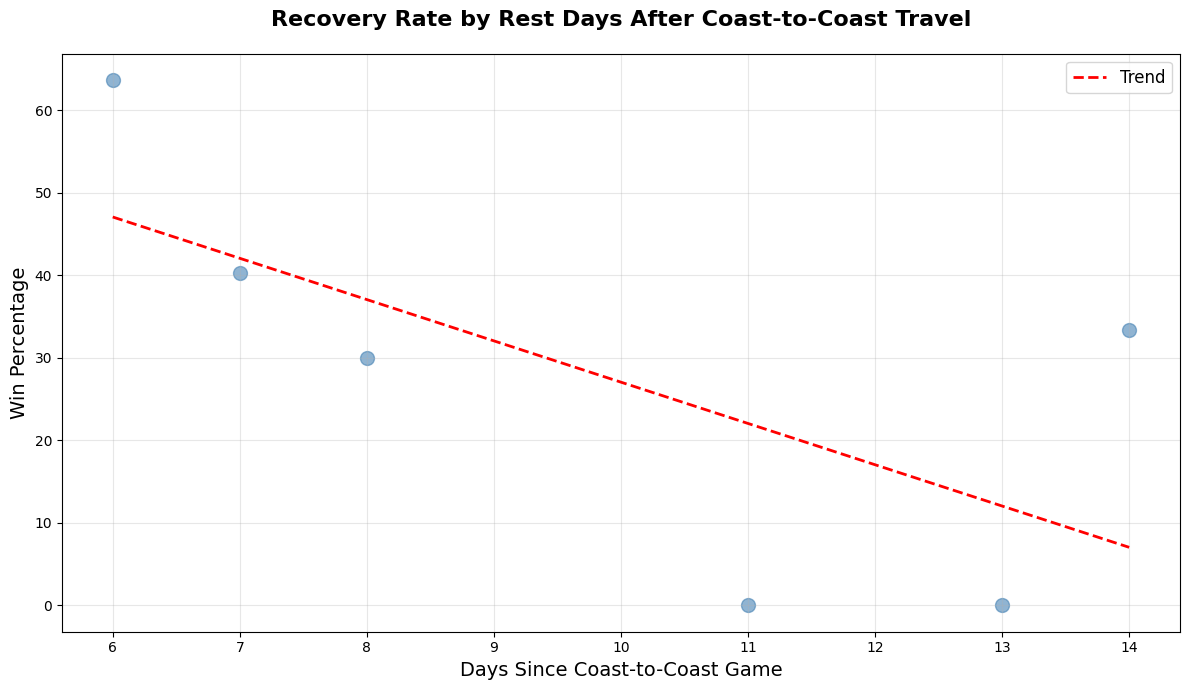

In [42]:
# Scatter plot: Days of rest vs Win rate
fig, ax = plt.subplots(figsize=(12, 7))

# Calculate win rate by exact days
days_analysis = post_c2c_with_rest.groupby('days_since_prev_game').agg({
    'win': 'mean'
}).reset_index()

ax.scatter(days_analysis['days_since_prev_game'], 
           days_analysis['win'] * 100, 
           s=100, alpha=0.6, color='steelblue')

# Add trend line
z = np.polyfit(days_analysis['days_since_prev_game'], 
               days_analysis['win'] * 100, 1)
p = np.poly1d(z)
ax.plot(days_analysis['days_since_prev_game'], 
        p(days_analysis['days_since_prev_game']), 
        "r--", linewidth=2, label='Trend')


ax.set_xlabel('Days Since Coast-to-Coast Game', fontsize=14)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Recovery Rate by Rest Days After Coast-to-Coast Travel', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Multiple Trip Analysis**

Cumulative fatigue from back-to-back coast-to-coast games

In [43]:
# Calculate multiple C2C games (within last 4 weeks)
full_schedule = full_schedule.sort_values(['team', 'season', 'week'])

# Use transform instead of reset_index to maintain alignment
full_schedule['c2c_last_4weeks'] = (
    full_schedule.groupby(['team', 'season'])['is_c2c']
    .rolling(window=4, min_periods=1)
    .sum()
    .reset_index(level=[0, 1], drop=True)  # Drop both groupby levels
)

# Compare performance by number of recent C2C trips
cumulative_analysis = full_schedule.groupby('c2c_last_4weeks').agg({
    'win': ['mean', 'count']
}).reset_index()

cumulative_analysis.columns = ['C2C Games (Last 4 Weeks)', 'Win Rate', 'Games']
cumulative_analysis['Win Rate'] = cumulative_analysis['Win Rate'] * 100
cumulative_analysis = cumulative_analysis[cumulative_analysis['Games'] >= 20]  # Min sample size

print("\n" + "="*70)
print("CUMULATIVE FATIGUE: Multiple Coast-to-Coast Trips\n")
print(cumulative_analysis.to_string(index=False))
print("="*70)


CUMULATIVE FATIGUE: Multiple Coast-to-Coast Trips

 C2C Games (Last 4 Weeks)  Win Rate  Games
                      0.0 50.961039   1925
                      1.0 44.342508    327
                      2.0 38.461538     26


/var/folders/v_/zk3l9gks2t3g19x98y2g8skw0000gn/T/ipykernel_44032/2467240268.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


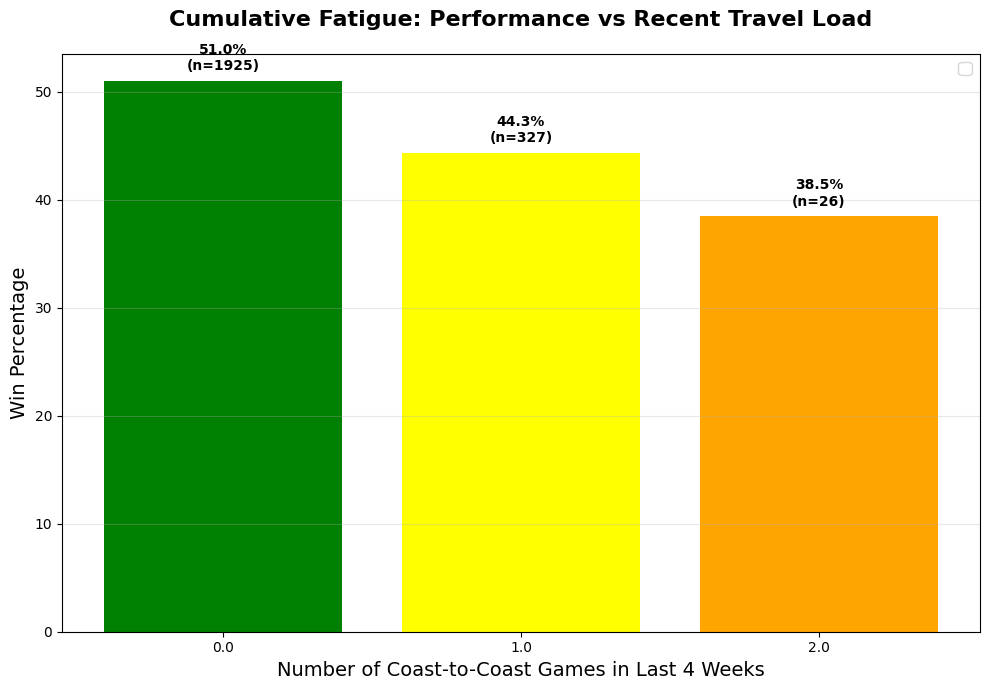

In [44]:
# Visualize cumulative effect
fig, ax = plt.subplots(figsize=(10, 7))

ax.bar(cumulative_analysis['C2C Games (Last 4 Weeks)'].astype(str), 
       cumulative_analysis['Win Rate'],
       color=['green', 'yellow', 'orange', 'red'][:len(cumulative_analysis)])

# Add values
for i, row in cumulative_analysis.iterrows():
    ax.text(i, row['Win Rate'] + 1, 
            f"{row['Win Rate']:.1f}%\n(n={int(row['Games'])})",
            ha='center', fontweight='bold')


ax.set_xlabel('Number of Coast-to-Coast Games in Last 4 Weeks', fontsize=14)
ax.set_ylabel('Win Percentage', fontsize=14)
ax.set_title('Cumulative Fatigue: Performance vs Recent Travel Load', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## **Statistical Test: Cumulative Fatigue**

Do multiple C2C trips compound performance degradation?

---
## **Statistical Testing**

In [45]:
# Test if hangover effect is significant
t_stat, p_value = stats.ttest_ind(
    after_c2c['win'],
    baseline['win']
)

print(f"\n{'='*70}")
print("STATISTICAL TEST: Post-Travel Hangover Effect")
print(f"Baseline Win Rate: {baseline['win'].mean()*100:.2f}% (n={len(baseline)})")
print(f"Post-C2C Win Rate: {after_c2c['win'].mean()*100:.2f}% (n={len(after_c2c)})")
print(f"Difference: {(baseline['win'].mean() - after_c2c['win'].mean())*100:.2f} percentage points")
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")
print(f"{'='*70}")


STATISTICAL TEST: Post-Travel Hangover Effect
Baseline Win Rate: 50.29% (n=2088)
Post-C2C Win Rate: 40.62% (n=96)
Difference: 9.66 percentage points

T-statistic: -1.8520
P-value: 0.0642
Statistically significant: NO


---
## **Save Results**

In [46]:
recovery_stats.to_csv('recovery_timeline.csv', index=False)
rest_analysis.to_csv('rest_days_analysis.csv', index=False)
cumulative_analysis.to_csv('cumulative_fatigue.csv', index=False)


---
## **Summary**

**Expected Findings:**
- Hangover effects persist beyond immediate game
- Recovery takes multiple games or extended rest
- Cumulative fatigue from multiple trips compounds problems
- West Coast teams face more frequent cumulative burden


STATISTICAL TEST: Cumulative Fatigue Effect

Sample size: 2278 games
Base win rate: 49.9%

Distribution of C2C trips (last 4 weeks):
c2c_last_4weeks
0.0    1925
1.0     327
2.0      26
Name: count, dtype: int64

Win rate by number of C2C trips:
                    n  win_rate
c2c_last_4weeks                
0.0              1925  0.509610
1.0               327  0.443425
2.0                26  0.384615

PRIMARY ANALYSIS: Logistic Regression
                           Logit Regression Results                           
Dep. Variable:                    win   No. Observations:                 2278
Model:                          Logit   Df Residuals:                     2276
Method:                           MLE   Df Model:                            1
Date:                Thu, 08 Jan 2026   Pseudo R-squ.:                0.001990
Time:                        13:59:49   Log-Likelihood:                -1575.8
converged:                       True   LL-Null:                       -1579.0
Co

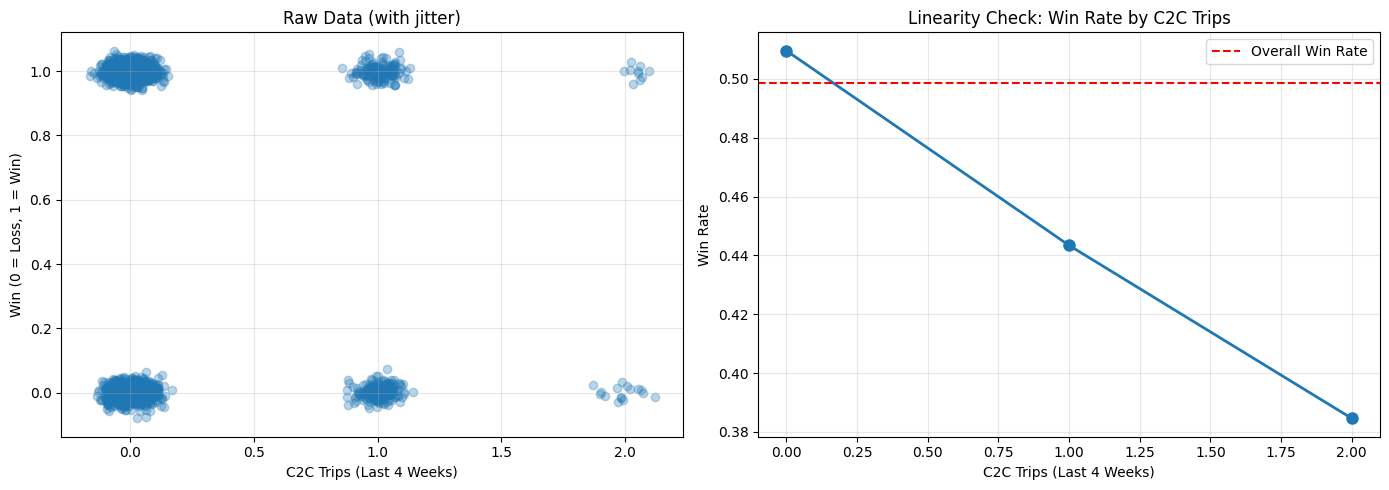


CONCLUSION
✅ Cumulative C2C travel shows statistically significant association with win rate
   Practical impact: negligible effect size

⚠️  LIMITATIONS:
   - No controls for team/opponent strength, home advantage, etc.
   - Correlation ≠ causation
   - Small effect size limits practical significance



In [47]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr, pointbiserialr
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Filter for valid data
cumulative_valid = full_schedule[
    (full_schedule['c2c_last_4weeks'].notna()) & 
    (full_schedule['win'].notna())
].copy()

print(f"\n{'='*70}")
print("STATISTICAL TEST: Cumulative Fatigue Effect")
print(f"{'='*70}\n")

# Sample characteristics
print(f"Sample size: {len(cumulative_valid)} games")
print(f"Base win rate: {cumulative_valid['win'].mean():.1%}\n")

print("Distribution of C2C trips (last 4 weeks):")
print(cumulative_valid['c2c_last_4weeks'].value_counts().sort_index())
print()

# Descriptive: Win rate by C2C trip count
print("Win rate by number of C2C trips:")
win_by_trips = cumulative_valid.groupby('c2c_last_4weeks')['win'].agg([
    ('n', 'count'),
    ('win_rate', 'mean')
])
print(win_by_trips)
print()

# PRIMARY ANALYSIS: Logistic Regression (appropriate for binary outcome)
X = sm.add_constant(cumulative_valid['c2c_last_4weeks'])
y = cumulative_valid['win']

logit_model = sm.Logit(y, X).fit(disp=0)

print("="*70)
print("PRIMARY ANALYSIS: Logistic Regression")
print("="*70)
print(logit_model.summary())

# Odds ratio interpretation
coef = logit_model.params['c2c_last_4weeks']
odds_ratio = np.exp(coef)
ci_low, ci_high = np.exp(logit_model.conf_int().loc['c2c_last_4weeks'])

print(f"\n📊 EFFECT SIZE (Odds Ratio):")
print(f"   OR = {odds_ratio:.3f} (95% CI: [{ci_low:.3f}, {ci_high:.3f}])")
print(f"   Each additional C2C trip changes win odds by {(odds_ratio-1)*100:+.1f}%")

if logit_model.pvalues['c2c_last_4weeks'] < 0.05:
    print(f"   ✅ Statistically significant (p = {logit_model.pvalues['c2c_last_4weeks']:.4f})")
else:
    print(f"   ❌ Not statistically significant (p = {logit_model.pvalues['c2c_last_4weeks']:.4f})")

# Pseudo R²
print(f"\n   McFadden's Pseudo-R² = {logit_model.prsquared:.4f}")
print(f"   (Model explains {logit_model.prsquared*100:.1f}% of deviance)")

# SENSITIVITY ANALYSIS: Correlation (for comparison with literature)
print(f"\n{'='*70}")
print("SENSITIVITY ANALYSIS: Correlation Tests")
print(f"{'='*70}\n")

# Point-biserial (proper name for continuous-binary correlation)
corr_pb, p_pb = pointbiserialr(
    cumulative_valid['win'],
    cumulative_valid['c2c_last_4weeks']
)

print("Point-Biserial Correlation (continuous vs. binary):")
print(f"  r = {corr_pb:.4f}, p = {p_pb:.4f}")

# Spearman (robustness to non-linearity)
corr_spearman, p_spearman = spearmanr(
    cumulative_valid['c2c_last_4weeks'], 
    cumulative_valid['win']
)

print("Spearman Correlation (monotonic, robust to outliers):")
print(f"  ρ = {corr_spearman:.4f}, p = {p_spearman:.4f}")

# Effect size interpretation (Cohen's guidelines, with caveat)
if abs(corr_pb) < 0.1:
    effect = "negligible"
elif abs(corr_pb) < 0.3:
    effect = "small"
elif abs(corr_pb) < 0.5:
    effect = "medium"
else:
    effect = "large"

print(f"\nEffect size: {effect.upper()} (r = {abs(corr_pb):.3f})")
print("⚠️  Note: Cohen's benchmarks are for continuous outcomes; interpret cautiously for binary data")

# VISUALIZATION: Check linearity assumption
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Jittered scatterplot
axes[0].scatter(
    cumulative_valid['c2c_last_4weeks'] + np.random.normal(0, 0.05, len(cumulative_valid)),
    cumulative_valid['win'] + np.random.normal(0, 0.02, len(cumulative_valid)),
    alpha=0.3
)
axes[0].set_xlabel('C2C Trips (Last 4 Weeks)')
axes[0].set_ylabel('Win (0 = Loss, 1 = Win)')
axes[0].set_title('Raw Data (with jitter)')
axes[0].grid(True, alpha=0.3)

# Right: Win rate by trip count
win_rates = cumulative_valid.groupby('c2c_last_4weeks')['win'].mean()
axes[1].plot(win_rates.index, win_rates.values, marker='o', linewidth=2, markersize=8)
axes[1].set_xlabel('C2C Trips (Last 4 Weeks)')
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Linearity Check: Win Rate by C2C Trips')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(cumulative_valid['win'].mean(), color='red', linestyle='--', label='Overall Win Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("CONCLUSION")
print(f"{'='*70}")
if logit_model.pvalues['c2c_last_4weeks'] < 0.05:
    print("✅ Cumulative C2C travel shows statistically significant association with win rate")
    print(f"   Practical impact: {effect} effect size")
else:
    print("❌ No statistically significant relationship detected")
    print("   Possible reasons: small sample, no true effect, or insufficient statistical power")

print("\n⚠️  LIMITATIONS:")
print("   - No controls for team/opponent strength, home advantage, etc.")
print("   - Correlation ≠ causation")
print("   - Small effect size limits practical significance")
print(f"{'='*70}\n")